In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor

In [2]:
# load dataset
df = pd.read_csv("/Users/krisqi/ACCFIN5230_lab_workspace/lab_1/loan.csv")

# dataset inspection
df.head()
# print(df.info())
# print(df.describe())

,int.rate,installment,log.annual.inc,dti,fico
0,0.1608,35.20,10.308953,23.84,642
1,0.1608,246.38,12.152144,22.47,647
2,0.1600,787.53,11.264464,19.34,682
3,0.1640,126.40,10.308953,29.60,677
4,0.1482,242.05,10.714418,19.12,652


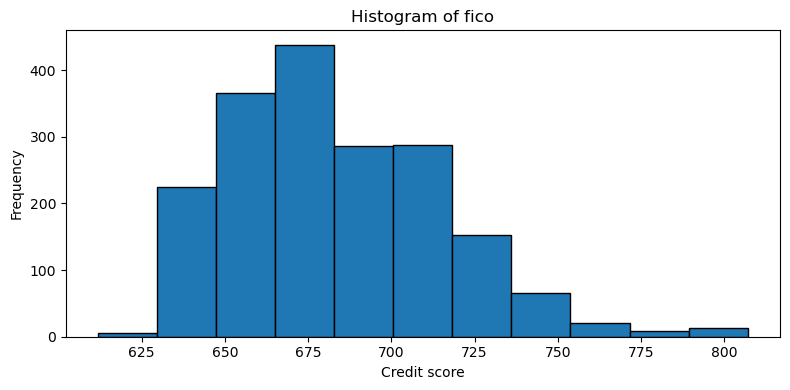

In [3]:
plt.figure(figsize=(8,4))
plt.hist(df['fico'], bins = 11, edgecolor = "black")
plt.title('Histogram of fico')
plt.xlabel('Credit score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


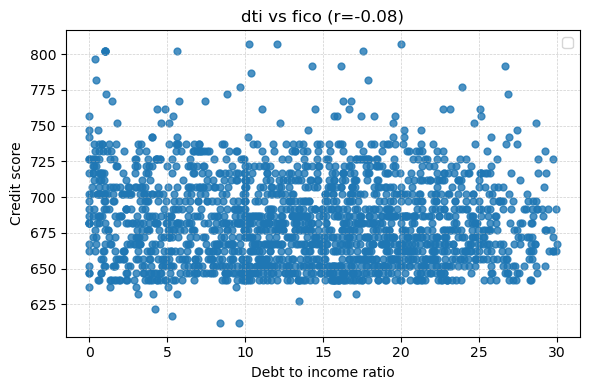

In [14]:
x = df['dti']
y = df['fico']

# s, i = np.polyfit(x, y, 1)
# line = np.linspace(x.min(), x.max(), 100)
# r = np.corrcoef(x, y)[0, 1]


fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x, y, s=24, alpha=0.8)
# ax.plot(line, s*line + i, color = 'red', label = 'Trend line')
ax.set_title(f'dti vs fico (r={r:.2f})')
ax.set_xlabel('Debt to income ratio')
ax.set_ylabel('Credit score')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.legend()
plt.show()

In [5]:
# normalize dataset

def nomalize (x):
    """
    nom_x = (x-min)/(max-min)
    
    """
    nomalized_data = ((x-min(x))/(max(x) - min(x)))
    return nomalized_data

In [ ]:
std_df = df.apply(nomalize)
std_df

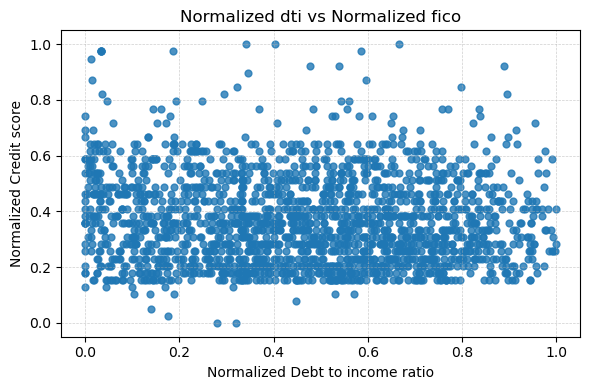

In [ ]:
# plot normalized dti as x with dico as y

x = std_df['dti']
y = std_df['fico']

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x, y, s=24, alpha=0.8)
ax.set_title('Normalized dti vs Normalized fico')
ax.set_xlabel('Normalized Debt to income ratio')
ax.set_ylabel('Normalized Credit score')
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.show()



## Why does dataset need to be normalised? 

Normalizing data in data science is essential to scale features to a similar range, preventing variables with large magnitudes from dominating models and ensuring equal contribution from all features.

It accelerates *gradient descent* **convergence** for machine learning algorithms (e.g., neural networks, linear regression) and improves the accuracy of distance-based models like KNN and K-Mean

In [8]:
# splitting trainning data and test data

X = std_df[['int.rate', 'installment', 'log.annual.inc', 'dti']]
Y = std_df['fico']

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=11,
)

x_train = X_train
x_test  = X_test
y_train = Y_train
y_test  = Y_test

In [9]:
# design a MLP and fitting data to MLP

nn = MLPRegressor(
    hidden_layer_sizes = (2,), # one hidden layer with 2 units
    activation = 'relu',
    max_iter = 1000,
    random_state = 11
)

nn.fit(x_train, y_train)

MLPRegressor(hidden_layer_sizes=(2,), max_iter=1000, random_state=11)

### Designed MLP plot show:
![img](/Users/krisqi/ACCFIN5230_lab_workspace/lab_1/MPL(2,).png)

In [10]:
# out-of-sample prediction:
y_pred = nn.predict(x_test)

# combining y_pred and y_test as dateframe
results_df = pd.DataFrame({
    "Groundtruth":y_test.values,
    "Prediction":y_pred
})
results_df.head()

,Groundtruth,Prediction
0,0.230769,0.323176
1,0.307692,0.324508
2,0.538462,0.592829
3,0.205128,0.253160
4,0.282051,0.349692


In [11]:
# inspection of results:

y_min = y_test.min()
y_max = y_test.max()
y_range = y_max - y_min

print("min:", y_min)
print("max:", y_max)
print("range:", y_range)

min: 0.10256410256410256
max: 0.9743589743589743
range: 0.8717948717948718


In [ ]:
# transforming to original scale

"""
nom_x = (x-min)/(max-min)
so,
x = nom_x * (max-min) + min

"""

ori_pred = results_df['Prediction'] * y_range + y_min
ori_act = results_df['Groundtruth'] * y_range + y_min

originalScaledPrediction = pd.DataFrame({
    "Prediction": ori_pred,
    "Groundtruth": ori_act
})

display(originalScaledPrediction)

,Prediction,Groundtruth
0,0.384307,0.303748
1,0.385469,0.370809
2,0.619390,0.571992
3,0.323267,0.281394
4,0.407423,0.348455
...,...,...
369,0.427068,0.393162
370,0.556254,0.661407
371,0.379555,0.281394
372,0.430009,0.437870


In [ ]:
# accuracy calculation manually
deviation = np.where(
    ori_act != 0, 
    (ori_act - ori_pred) / ori_act, 
    0
)

comparison = pd.DataFrame({
    "Prediction": ori_pred,
    "Groundtruth":ori_act,
    "Deviation": deviation
})

accuracy = 1 - abs(np.mean(deviation))
print("Accuracy:", accuracy)
comparison.head()

Accuracy: 0.9165502541632493


,Prediction,Groundtruth,Deviation
0,0.384307,0.303748,-0.265219
1,0.385469,0.370809,-0.039535
2,0.619390,0.571992,-0.082864
3,0.323267,0.281394,-0.148808
4,0.407423,0.348455,-0.169228


In [22]:
# Prediction and accuracy by sklearn MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(ori_act, ori_pred)
mse = mean_squared_error(ori_act, ori_pred)
rmse = np.sqrt(mse)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Accuracy:", 1-mae/y_range)
print("Accuracy:", 1-rmse/y_range)

Mean Absolute Error (MAE): 0.08615105289576667
Mean Squared Error (MSE): 0.010985447425538891
Root Mean Squared Error (RMSE): 0.10481148517953026
Accuracy: 0.9011796746195617
Accuracy: 0.8797750611175976


# Why are they different? 
